# Lab 2: MATLAB Basics

**课程**：经济与商务实证研究方法（RMEB） 2026 Spring  
**主题**：MATLAB 入门与 VS Code 一体化工作流  
**定位**：Week 2 计算环境搭建的配套实验

## 学习目标

完成本 notebook 后，你应该能够：

1. 在 VS Code 中直接运行 MATLAB notebook。
2. 理解 MATLAB 的变量、向量和矩阵操作。
3. 创建一个简单表格并做基础统计。
4. 固定随机种子并画出直方图。

## 为什么 MATLAB 也要进 VS Code？

MATLAB 在数值计算和矩阵运算上非常强，但如果教学还停留在单独打开 MATLAB 窗口、单独记笔记、单独找 AI 帮助，学习成本会被人为放大。

更高效的方式是：

- 在 **VS Code** 统一写 notebook、看图、记解释。
- 让 **Copilot** 帮你补全矩阵和绘图代码。
- 让 **Claude Code** 帮你解释数值结果、重构演示顺序和调试错误。

**重点是把 MATLAB 也纳入统一、可重复、可审计的 AI 协同工作流。**

## 环境要求

运行本 notebook 前，请确保：

- VS Code 已安装 Jupyter 扩展。
- 当前 notebook 连接到 `Matlab` kernel。
- 本机已安装 MATLAB，并已完成 MATLAB kernel 注册。

这份材料强调的是：即使是 MATLAB，也可以放进统一的 notebook + AI 协作工作流，而不必把思考和执行分散到多个软件窗口。

In [2]:
version
matlabroot


ans =

    '24.1.0.2603908 (R2024a) Update 3'


ans =

    '/Applications/MATLAB_R2024a.app'



## 1. 基本语法与向量

In [3]:
courseName = 'RMEB';
week = 2;
scores = [88, 92, 79, 95, 90];

disp(courseName)
disp(week)
disp(scores)
disp(mean(scores))

RMEB
     2

    88    92    79    95    90

   88.8000



## 2. 矩阵与表格

In [4]:
X = [1 2; 3 4; 5 6];
disp(X)

id = [1; 1; 2; 2; 3; 3];
year = [2024; 2025; 2024; 2025; 2024; 2025];
treatment = [0; 1; 0; 0; 1; 1];
outcome = [10.2; 11.5; 9.8; 10.0; 12.1; 12.7];

T = table(id, year, treatment, outcome)
T.outcome_gap = T.outcome - mean(T.outcome);
T

     1     2
     3     4
     5     6


T =

  6x4 table

    id    year    treatment    outcome
    __    ____    _________    _______

    1     2024        0         10.2  
    1     2025        1         11.5  
    2     2024        0          9.8  
    2     2025        0           10  
    3     2024        1         12.1  
    3     2025        1         12.7  


T =

  6x5 table

    id    year    treatment    outcome    outcome_gap
    __    ____    _________    _______    ___________

    1     2024        0         10.2         -0.85   
    1     2025        1         11.5          0.45   
    2     2024        0          9.8         -1.25   
    2     2025        0           10         -1.05   
    3     2024        1         12.1          1.05   
    3     2025        1         12.7          1.65   



## 3. 随机数与直方图


ans =

   -0.0105


ans =

    1.0430



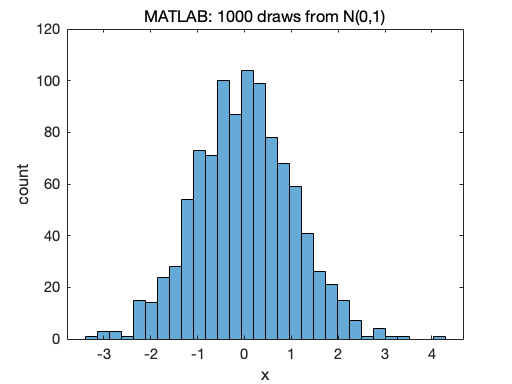

In [5]:
rng(42)
x = randn(1000,1);
mean(x)
std(x)
histogram(x, 30)
title('MATLAB: 1000 draws from N(0,1)')
xlabel('x')
ylabel('count')

## 4. 循环与控制流

MATLAB 提供 `for` 和 `while` 循环，但许多场景下**向量化操作**比循环更高效。

In [ ]:
%% --- for 循环 ---
disp('=== for 循环 ===')
for i = 1:5
    fprintf('i = %d\n', i);
end

% 遍历数组
fruits = {'苹果', '香蕉', '橙子'};
for k = 1:length(fruits)
    fprintf('第%d个: %s\n', k, fruits{k});
end

%% --- while 循环 ---
disp(newline + "=== while 循环 ===")
n = 1; total = 0;
while n <= 10
    total = total + n;
    n = n + 1;
end
fprintf('1到10的和 = %d\n', total);

%% --- if/elseif/else ---
score = 85;
if score >= 90
    grade = '优秀';
elseif score >= 80
    grade = '良好';
else
    grade = '需努力';
end
fprintf('成绩: %s\n', grade);

%% --- switch/case ---
day = 'Mon';
switch day
    case {'Mon', 'Tue', 'Wed', 'Thu', 'Fri'}
        disp('工作日')
    case {'Sat', 'Sun'}
        disp('周末')
    otherwise
        disp('未知')
end

%% --- 向量化 vs 循环（性能对比）---
N = 1000000;

% 循环方式
tic;
result_loop = zeros(1, N);
for i = 1:N
    result_loop(i) = sin(i) + cos(i);
end
t_loop = toc;

% 向量化方式
tic;
x = 1:N;
result_vec = sin(x) + cos(x);
t_vec = toc;

fprintf('循环耗时: %.4f 秒\n', t_loop);
fprintf('向量化耗时: %.4f 秒\n', t_vec);
fprintf('加速比: %.1fx\n', t_loop / t_vec);

## 5. 函数的写法

MATLAB 函数可以定义在脚本末尾（`local function`）或独立 `.m` 文件中。匿名函数用 `@` 定义。

In [ ]:
%% --- 匿名函数 ---
square = @(x) x.^2;
fprintf('square(5) = %d\n', square(5));

% 多参数匿名函数
hypotenuse = @(a, b) sqrt(a.^2 + b.^2);
fprintf('斜边长 = %.2f\n', hypotenuse(3, 4));

%% --- local function（脚本内定义）---
% 注意：在 Jupyter/Live Script 中，local function 需要放在代码块末尾

% 调用 local function
data = [2, 4, 6, 8, 10];
[mu, sigma] = compute_stats(data);
fprintf('均值 = %.2f, 标准差 = %.2f\n', mu, sigma);

% 多返回值函数
function [mu, sigma] = compute_stats(x)
    mu = mean(x);
    sigma = std(x);
end

%% --- 函数句柄 (function handle) ---
% 像变量一样传递函数
operations = {@sin, @cos, @tan};
x_val = pi/4;
for k = 1:length(operations)
    fprintf('%s(π/4) = %.4f\n', func2str(operations{k}), operations{k}(x_val));
end

% 常见用途：传给 fminbnd, integral, ode45 等
f = @(x) x.^2 - 4*x + 3;
x_min = fminbnd(f, 0, 4);
fprintf('f(x)=x²-4x+3 在 [0,4] 最小值点: x = %.2f\n', x_min);

## 6. 高级用法入门

### 6.1 结构体 (struct) 与元胞数组 (cell array)

`struct` 用于存储异构数据（如面板数据的元信息），`cell array` 可以混合存储不同类型。

### 6.2 逻辑索引与向量化技巧

MATLAB 最强大的特性之一——用逻辑条件直接筛选数据，无需循环。

### 6.3 表格 (table) 与数据处理

`table` 是 MATLAB 处理结构化数据的现代方式，类似 Python 的 DataFrame。

In [ ]:
%% ===== 6.1 结构体与元胞数组 =====
% 结构体 (struct)
student.name = '张三';
student.score = 92.5;
student.courses = {'计量', '微观', '宏观'};
fprintf('%s 的成绩: %.1f\n', student.name, student.score);

% 结构体数组
students(1) = struct('name', '张三', 'score', 92.5);
students(2) = struct('name', '李四', 'score', 87.0);
students(3) = struct('name', '王五', 'score', 95.0);
for k = 1:length(students)
    fprintf('%s: %.1f\n', students(k).name, students(k).score);
end

% 元胞数组 (cell array)：混合类型存储
mixed = {'文本', 42, [1 2 3], @sin};
fprintf('类型: %s, 值: %s\n', class(mixed{1}), mixed{1});
fprintf('类型: %s, 值: %d\n', class(mixed{2}), mixed{2});

%% ===== 6.2 逻辑索引与向量化 =====
rng(42);
data = randn(1, 1000);  % 1000个正态随机数

% 逻辑索引：筛选正数
positives = data(data > 0);
fprintf('正数比例: %.1f%%\n', length(positives)/length(data)*100);

% 条件替换（无需循环）
capped = data;
capped(capped > 2) = 2;    % 上限截断
capped(capped < -2) = -2;  % 下限截断
fprintf('截断后范围: [%.2f, %.2f]\n', min(capped), max(capped));

% arrayfun：对数组逐元素应用函数
labels = arrayfun(@(x) string(sprintf('%.1f', x)), data(1:5));
disp(labels);

%% ===== 6.3 表格 (table) =====
% 创建表格
Name = {'张三'; '李四'; '王五'; '赵六'};
Age = [22; 24; 23; 25];
GPA = [3.8; 3.5; 3.9; 3.2];
Major = categorical({'经济'; '金融'; '经济'; '管理'});

T = table(Name, Age, GPA, Major);
disp(T);

% 筛选：GPA > 3.5
disp('GPA > 3.5 的学生:');
disp(T(T.GPA > 3.5, :));

% 按专业分组统计
disp('按专业统计平均GPA:');
G = groupsummary(T, 'Major', 'mean', 'GPA');
disp(G);

% 排序
T_sorted = sortrows(T, 'GPA', 'descend');
disp('按GPA降序:');
disp(T_sorted);

## ✨ MATLAB 杀手锏预览：矩阵就是语言本身

MATLAB（**Mat**rix **Lab**oratory）为矩阵运算而生。在结构模型估计、数值优化、矩阵分解中，MATLAB 的表达力无人能及——`(X' * X) \ (X' * y)` 就是 OLS 公式本身。

> 💡 **研究中的组合优势**：MATLAB 求解结构模型 + Stata 做 reduced-form 验证 + Python 做数据预处理，是产业组织（IO）研究的经典组合。

In [2]:
% MATLAB 的杀手锏：矩阵运算 + 优化一气呵成
% OLS 的矩阵解 vs 优化器解 — 殊途同归

% 生成模拟数据
rng(42);
n = 100;
X = [ones(n,1), randn(n,1), randn(n,1)];
beta_true = [2; -1.5; 0.8];
y = X * beta_true + 0.5 * randn(n,1);

% 方法1：一行矩阵公式（正规方程）— 这就是 MATLAB 的优雅
beta_ols = (X' * X) \ (X' * y);

% 方法2：用优化器求解（展示灵活性）
loss = @(b) sum((y - X * b).^2);
beta_opt = fminsearch(loss, zeros(3,1));

% 对比
fprintf('真实参数:    [%.4f, %.4f, %.4f]\n', beta_true);
fprintf('OLS矩阵解:  [%.4f, %.4f, %.4f]\n', beta_ols);
fprintf('优化器解:    [%.4f, %.4f, %.4f]\n', beta_opt);
fprintf('\n两种方法殊途同归 — 但矩阵解只需一行！')

真实参数:    [2.0000, -1.5000, 0.8000]
OLS矩阵解:  [2.0346, -1.5179, 0.7370]
优化器解:    [2.0346, -1.5178, 0.7370]

两种方法殊途同归 — 但矩阵解只需一行！

## 4. 练习

1. 把 `x = randn(1000,1)` 改成均值 5、标准差 2 的正态样本。
2. 在表格 `T` 中新增变量 `treated_outcome = treatment .* outcome`。
3. 让 Copilot 帮你把这个 notebook 扩展为一个简单 Monte Carlo 演示。

In [ ]:
% TODO: 在这里写你的练习代码